# INNE (Isolation using Nearest Neighbor Ensemble) for Fraud Anomaly Detection

This script uses the unified_dataset.csv and applies the INNE algorithm for fraud anomaly detection. INNE (isolation using Nearest Neighbor Ensemble) is an unsupervised anomaly detection method that uses nearest-neighbor-based isolation. Unlike iForest which uses trees for isolation, INNE partitions the data space into hypersphere regions using subsamples and determines an isolation score based on how isolated a point is from its nearest neighbors.

**Advantages over LOF (which this replaces in the ensemble):**
- Linear time complexity and constant space complexity (much faster than LOF on large/high-dimensional data)
- Detects both local and global anomalies
- Handles high-dimensional data with irrelevant attributes
- Overcomes weaknesses of iForest (local anomalies, axis-parallel masking, multimodal data)

The notebook includes:
- Data preprocessing with standard scaling
- **AUPRC-based hyperparameter tuning** (uses labeled fraud samples for validation)
- Anomaly score analysis
- Feature importance for anomaly detection
- Visualization of detected anomalies
- **Confusion matrix based on top 5% anomalous threshold**
- **Model export for ensemble integration**

The test data is 40% of the original data. This script takes 20 minutes to run!

In [1]:
!pip install pyod --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.inne import INNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load and Prepare Data

In [3]:
# Load the dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (140827, 67)

First few rows:


,npi,target,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplrs_median,tot_suplrs_min,tot_suplr_clms_min,tot_suplr_srvcs_min,...,tot_suplr_benes_sum_zscore_by_type,tot_suplr_srvcs_max_zscore,total_payment_zscore_by_type,bene_avg_age_zscore_by_type,bene_avg_risk_scre_zscore_by_type,submitted_to_standardized_ratio_zscore,submitted_to_standardized_ratio_zscore_by_type,claims_per_bene_zscore_by_type,services_per_bene_zscore_by_type,benes_per_supplier_zscore_by_type
0,1003000597,0,1.692306,1.692306,1.692306,1.0,3.0,3,44,5955,...,-0.275616,-0.007007,-0.008424,-0.549574,-0.210703,-0.038129,-0.154682,3.003923,4.288024,-0.187419
1,1003000597,0,23.833223,0.112054,8.331875,5.0,3.0,1,17,32,...,-0.219804,0.045155,-0.010997,-0.115403,-0.311213,-0.082280,-0.424691,1.564890,2.626744,-0.159271
2,1003000902,0,155.711788,0.087436,82.163333,5.0,2.5,1,12,12,...,-0.145469,-0.091197,-0.065875,-0.363841,0.187261,0.015906,-0.018203,-0.036876,-0.073170,-0.092180
3,1003000902,0,67.361088,0.028794,38.227500,4.0,3.0,1,11,12,...,-0.261960,-0.075164,-0.073111,-1.214294,-0.554692,0.061148,0.299657,-0.374303,0.108292,-0.098162
4,1003000902,0,40.802223,0.098643,24.145333,3.0,3.5,1,11,11,...,-0.344188,-0.088898,-0.059281,-0.835965,-0.337922,-0.029850,-0.339677,-0.049636,0.152416,-0.091872


In [4]:
# Check for missing values
print("Missing values per column (top 20):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Missing values per column (top 20):
npi                                               0
submitted_charge_per_bene_pctile_by_type          0
bene_cc_ph_arthritis_v2_pct                       0
bene_cc_ph_stroke_tia_v2_pct                      0
form_count_cash_or_cash_equivalent                0
third_party_recipient_sum_individual              0
specialty_type                                    0
specialty                                         0
benes_per_supplier                                0
avg_suplr_sbmtd_chrg_mean_pctile_by_type          0
avg_suplr_sbmtd_chrg_max_pctile_by_type           0
tot_suplr_benes_sum_pctile_by_type                0
tot_suplr_srvcs_max_pctile_by_type                0
total_payment_pctile_by_type                      0
bene_avg_age_pctile_by_type                       0
bene_avg_risk_scre_pctile_by_type                 0
submitted_to_standardized_ratio_pctile_by_type    0
bene_cc_ph_ischemic_heart_v2_pct                  0
claims_per_bene_pctile_by_ty

In [5]:
# Define columns to exclude from modeling
# These are identifiers, targets, or non-predictive columns
exclude_cols = ['target', 'npi', 'year', 'Rfrg_NPI', 'covered_recipient_npi', 
                'fraud_flag', 'year_leie', 'excltype']

# Also exclude date columns
date_cols = [col for col in df.columns if 'date' in col.lower()]
exclude_cols.extend(date_cols)

# Select only numeric columns, excluding identifiers and target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Excluded columns: {[c for c in exclude_cols if c in df.columns]}")

# Create feature matrix
X = df[feature_cols].copy()

Number of feature columns: 63
Excluded columns: ['target', 'npi']


## Train-Test Split and Scaling

In [6]:
# Split data: 60% train, 40% test (stratified on target to preserve fraud ratio)
y = df['target'].values

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, X.index, test_size=0.4, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFraud in training set: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Fraud in test set: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Training set size: 84496 samples
Test set size: 56331 samples

Fraud in training set: 34 (0.0402%)
Fraud in test set: 22 (0.0391%)


In [7]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using scaler = StandardScaler()")
print(f"\nTraining data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features scaled using scaler = StandardScaler()

Training data - Mean: 0.0000, Std: 1.0000
Test data - Mean: -0.0019, Std: 1.0507


## AUPRC-Based Hyperparameter Tuning

Since we have a small set of labeled fraud samples (target=1), we use **Area Under the Precision-Recall Curve (AUPRC)** to tune hyperparameters:
- Train the INNE model unsupervised (it doesn't use labels)
- Evaluate anomaly scores against the known fraud labels using AUPRC
- AUPRC is ideal for highly imbalanced data where positive cases are rare
- We use stratified K-fold cross-validation to ensure fraud cases appear in every fold

**INNE Parameters:**
- `n_estimators`: Number of base estimators (hypersphere sets) in the ensemble
- `max_samples`: Number of samples drawn to build each set of hyperspheres (controls locality)
- `contamination`: Expected proportion of anomalies (used for threshold only)

In [8]:
def compute_auprc_score(X_data, y_data, params, n_splits=5):
    """
    Compute mean AUPRC for a given parameter set using stratified K-fold CV.
    
    The INNE model trains unsupervised, but we evaluate its anomaly
    scores against the known fraud labels using AUPRC.
    
    Returns:
        mean_auprc: Average AUPRC across folds
        std_auprc: Standard deviation of AUPRC across folds
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auprc_scores = []
    
    for fold_train_idx, fold_val_idx in skf.split(X_data, y_data):
        X_fold_train = X_data[fold_train_idx]
        X_fold_val = X_data[fold_val_idx]
        y_fold_val = y_data[fold_val_idx]
        
        # Skip folds with no positive samples in validation
        if y_fold_val.sum() == 0:
            continue
        
        model = INNE(
            n_estimators=params['n_estimators'],
            max_samples=params['max_samples'],
            contamination=params['contamination'],
            random_state=42
        )
        model.fit(X_fold_train)
        
        # Get anomaly scores (higher = more anomalous in PyOD)
        val_scores = model.decision_function(X_fold_val)
        
        # Compute AUPRC: anomaly scores as predictions, fraud labels as ground truth
        auprc = average_precision_score(y_fold_val, val_scores)
        auprc_scores.append(auprc)
    
    return np.mean(auprc_scores), np.std(auprc_scores)

print("AUPRC scoring function defined.")

AUPRC scoring function defined.


In [9]:
# Define hyperparameter grid for INNE
# n_estimators: number of hypersphere sets
# max_samples: subsample size (controls locality; smaller = more local)
# contamination: expected outlier fraction (for threshold only)
param_grid = {
    'n_estimators': [50, 300],
    'max_samples': [8, 32, 128],
    'contamination': [0.0003, 0.001, 0.005],
}
print(f"Running AUPRC-based hyperparameter tuning...")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Fraud samples in training: {y_train.sum()}")
print(f"Parameter combinations: {len(list(ParameterGrid(param_grid)))}")
print(f"Cross-validation folds: 5 (stratified)")

Running AUPRC-based hyperparameter tuning...
Training samples: 84496
Fraud samples in training: 34
Parameter combinations: 18
Cross-validation folds: 5 (stratified)


In [10]:
##############################################
# Run AUPRC-based grid search
###############################################
auprc_results = []

for params in ParameterGrid(param_grid):
    mean_auprc, std_auprc = compute_auprc_score(
        X_train_scaled, y_train, params, n_splits=5
    )
    
    auprc_results.append({
        **params,
        'mean_auprc': mean_auprc,
        'std_auprc': std_auprc
    })
    
    print(f"n_estimators={params['n_estimators']}, max_samples={params['max_samples']}, "
          f"contamination={params['contamination']} -> AUPRC: {mean_auprc:.4f} (+/- {std_auprc:.4f})")

# Convert to DataFrame and sort
auprc_df = pd.DataFrame(auprc_results).sort_values('mean_auprc', ascending=False)

print("\nTop Parameter Combinations by AUPRC:")
print(auprc_df.head())

n_estimators=50, max_samples=8, contamination=0.0003 -> AUPRC: 0.0012 (+/- 0.0007)
n_estimators=300, max_samples=8, contamination=0.0003 -> AUPRC: 0.0011 (+/- 0.0007)
n_estimators=50, max_samples=32, contamination=0.0003 -> AUPRC: 0.0019 (+/- 0.0020)
n_estimators=300, max_samples=32, contamination=0.0003 -> AUPRC: 0.0012 (+/- 0.0009)
n_estimators=50, max_samples=128, contamination=0.0003 -> AUPRC: 0.0010 (+/- 0.0004)
n_estimators=300, max_samples=128, contamination=0.0003 -> AUPRC: 0.0011 (+/- 0.0006)
n_estimators=50, max_samples=8, contamination=0.001 -> AUPRC: 0.0012 (+/- 0.0007)
n_estimators=300, max_samples=8, contamination=0.001 -> AUPRC: 0.0011 (+/- 0.0007)
n_estimators=50, max_samples=32, contamination=0.001 -> AUPRC: 0.0019 (+/- 0.0020)
n_estimators=300, max_samples=32, contamination=0.001 -> AUPRC: 0.0012 (+/- 0.0009)
n_estimators=50, max_samples=128, contamination=0.001 -> AUPRC: 0.0010 (+/- 0.0004)
n_estimators=300, max_samples=128, contamination=0.001 -> AUPRC: 0.0011 (+/- 

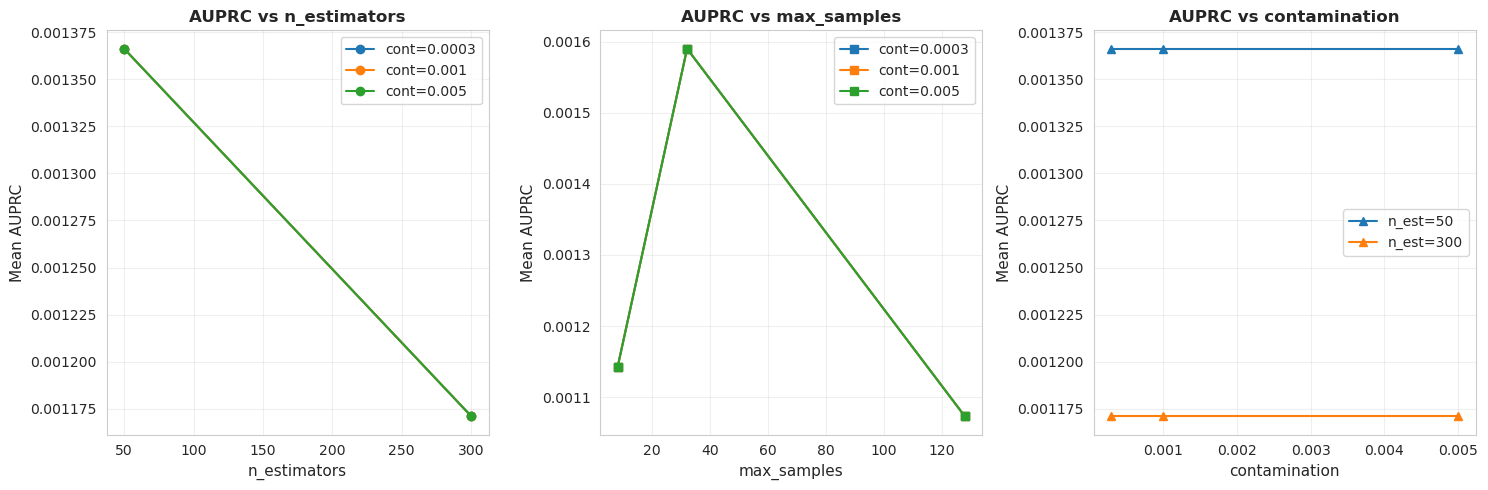

In [11]:
# Visualize AUPRC results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: AUPRC by n_estimators
for cont in param_grid['contamination']:
    subset = auprc_df[auprc_df['contamination'] == cont]
    grouped = subset.groupby('n_estimators')['mean_auprc'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'cont={cont}')
axes[0].set_xlabel('n_estimators', fontsize=11)
axes[0].set_ylabel('Mean AUPRC', fontsize=11)
axes[0].set_title('AUPRC vs n_estimators', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: AUPRC by max_samples
for cont in param_grid['contamination']:
    subset = auprc_df[auprc_df['contamination'] == cont]
    grouped = subset.groupby('max_samples')['mean_auprc'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='s', label=f'cont={cont}')
axes[1].set_xlabel('max_samples', fontsize=11)
axes[1].set_ylabel('Mean AUPRC', fontsize=11)
axes[1].set_title('AUPRC vs max_samples', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: AUPRC by contamination
for n_est in param_grid['n_estimators']:
    subset = auprc_df[auprc_df['n_estimators'] == n_est]
    grouped = subset.groupby('contamination')['mean_auprc'].mean()
    axes[2].plot(grouped.index, grouped.values, marker='^', label=f'n_est={n_est}')
axes[2].set_xlabel('contamination', fontsize=11)
axes[2].set_ylabel('Mean AUPRC', fontsize=11)
axes[2].set_title('AUPRC vs contamination', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('inne_auprc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
##############################################
# Select best parameters
###############################################
best_row = auprc_df.iloc[0]
best_params = best_row.to_dict()
best_auprc = best_params.pop('mean_auprc')
best_auprc_std = best_params.pop('std_auprc')

# Convert to proper types
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_samples'] = int(best_params['max_samples'])
best_params['contamination'] = float(best_params['contamination'])

print("Best Parameters (Highest AUPRC):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nAUPRC: {best_auprc:.4f} (+/- {best_auprc_std:.4f})")

Best Parameters (Highest AUPRC):
  contamination: 0.001
  max_samples: 32
  n_estimators: 50

AUPRC: 0.0019 (+/- 0.0020)


## Train Final Model with Best Parameters

In [13]:
##############################################
# Train Final Model
###############################################
print("Training final INNE model with best parameters...")

inne_model = INNE(
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    contamination=best_params['contamination'],
    random_state=42
)

inne_model.fit(X_train_scaled)

Training final INNE model with best parameters...


,n_estimators,50
,max_samples,32
,contamination,0.001
,random_state,42


In [27]:
# Get anomaly scores
train_scores = inne_model.decision_function(X_train_scaled)
test_scores = inne_model.decision_function(X_test_scaled)

# Use score-based top-k instead of predict() 
# (model threshold is unreliable at very low contamination)
TOP_K_PCT = 0.05

train_top_k = int(len(train_scores) * TOP_K_PCT)
test_top_k = int(len(test_scores) * TOP_K_PCT)

train_predictions = np.ones(len(train_scores), dtype=int)
train_predictions[np.argsort(train_scores)[-train_top_k:]] = -1

test_predictions = np.ones(len(test_scores), dtype=int)
test_predictions[np.argsort(test_scores)[-test_top_k:]] = -1

n_anomalies_train = np.sum(train_predictions == -1)
n_anomalies_test = np.sum(test_predictions == -1)

print(f"Training set anomalies (top {TOP_K_PCT*100:.0f}%): {n_anomalies_train} ({n_anomalies_train/len(train_predictions)*100:.2f}%)")
print(f"Test set anomalies (top {TOP_K_PCT*100:.0f}%): {n_anomalies_test} ({n_anomalies_test/len(test_predictions)*100:.2f}%)")

Training set anomalies (top 5%): 4224 (5.00%)
Test set anomalies (top 5%): 2816 (5.00%)


## Anomaly Score Distribution Analysis

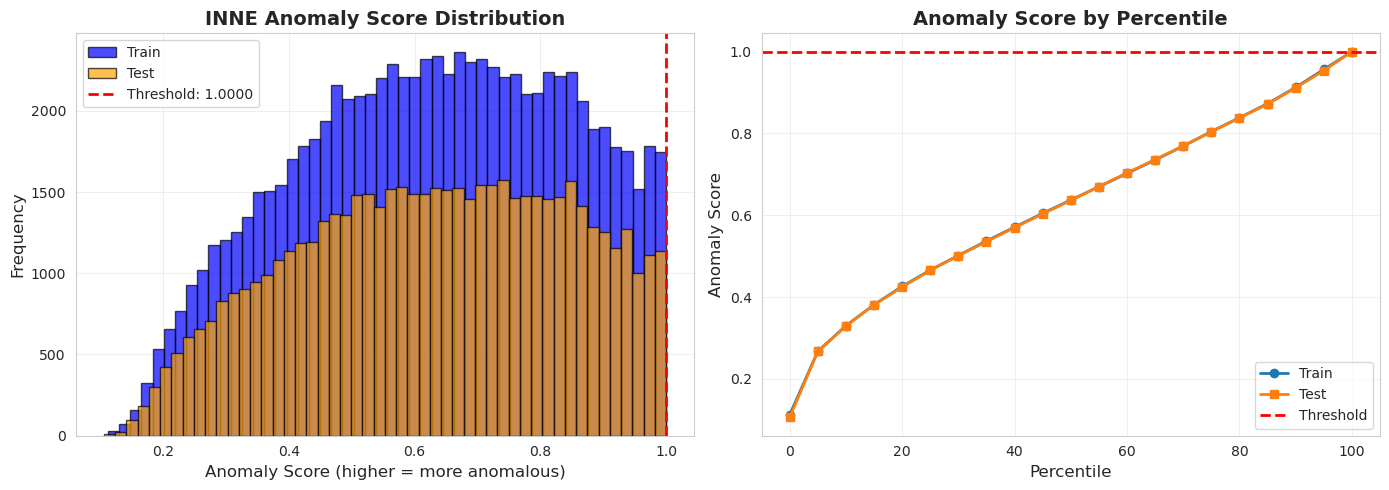

In [28]:
##############################################
# Viz Anomaly Scores
###############################################
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score distribution histogram
axes[0].hist(train_scores, bins=50, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(test_scores, bins=50, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0].axvline(x=inne_model.threshold_, color='red', linestyle='--', linewidth=2, label=f'Threshold: {inne_model.threshold_:.4f}')
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('INNE Anomaly Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Score by percentile
percentiles = np.arange(0, 101, 5)
train_percentile_scores = np.percentile(train_scores, percentiles)
test_percentile_scores = np.percentile(test_scores, percentiles)

axes[1].plot(percentiles, train_percentile_scores, marker='o', label='Train', linewidth=2)
axes[1].plot(percentiles, test_percentile_scores, marker='s', label='Test', linewidth=2)
axes[1].axhline(y=inne_model.threshold_, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('Anomaly Score', fontsize=12)
axes[1].set_title('Anomaly Score by Percentile', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inne_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Score statistics
print("INNE Score Statistics:")
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")

print(f"{'Mean':<20} {train_scores.mean():>12.4f} {test_scores.mean():>12.4f}")
print(f"{'Std':<20} {train_scores.std():>12.4f} {test_scores.std():>12.4f}")
print(f"{'Min':<20} {train_scores.min():>12.4f} {test_scores.min():>12.4f}")
print(f"{'25th Percentile':<20} {np.percentile(train_scores, 25):>12.4f} {np.percentile(test_scores, 25):>12.4f}")
print(f"{'Median':<20} {np.median(train_scores):>12.4f} {np.median(test_scores):>12.4f}")
print(f"{'75th Percentile':<20} {np.percentile(train_scores, 75):>12.4f} {np.percentile(test_scores, 75):>12.4f}")
print(f"{'95th Percentile':<20} {np.percentile(train_scores, 95):>12.4f} {np.percentile(test_scores, 95):>12.4f}")
print(f"{'99th Percentile':<20} {np.percentile(train_scores, 99):>12.4f} {np.percentile(test_scores, 99):>12.4f}")
print(f"{'Max':<20} {train_scores.max():>12.4f} {test_scores.max():>12.4f}")

INNE Score Statistics:
Metric                      Train         Test
Mean                       0.6287       0.6281
Std                        0.2125       0.2124
Min                        0.1122       0.1057
25th Percentile            0.4659       0.4651
Median                     0.6371       0.6364
75th Percentile            0.8047       0.8038
95th Percentile            0.9564       0.9534
99th Percentile            0.9951       0.9939
Max                        1.0000       1.0000


## Feature Importance Analysis

In [30]:
##############################################
# Analyze which features differentiate anomalies from normal samples
# Use top-k% by score instead of predict() labels to avoid empty groups
###############################################

# Verify we're using scaled data
print(f"X_test_scaled type: {type(X_test_scaled)}, mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")
# Should be ~0.0 mean and ~1.0 std. If not, re-run: X_test_scaled = scaler.transform(X_test)

TOP_K_PCT = 0.01
top_k = int(len(test_scores) * TOP_K_PCT)
top_k_indices = np.argsort(test_scores)[-top_k:]

anomaly_mask = np.zeros(len(test_scores), dtype=bool)
anomaly_mask[top_k_indices] = True
normal_mask = ~anomaly_mask

normal_means = X_test_scaled[normal_mask].mean(axis=0)
anomaly_means = X_test_scaled[anomaly_mask].mean(axis=0)

feature_importance = np.abs(anomaly_means - normal_means)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance,
    'normal_mean': normal_means,
    'anomaly_mean': anomaly_means,
    'difference': anomaly_means - normal_means
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Features Differentiating Anomalies from Normal Samples:")
print(f"(Based on top {TOP_K_PCT*100:.0f}% most anomalous by score, n={top_k})")
print(importance_df.head(20))

X_test_scaled type: <class 'numpy.ndarray'>, mean: -0.0019, std: 1.0507

Top 20 Features Differentiating Anomalies from Normal Samples:
(Based on top 1% most anomalous by score, n=563)
                                           feature  importance  normal_mean  \
55                    total_payment_zscore_by_type    3.765662    -0.022340   
37            third_party_recipient_sum_individual    2.348764    -0.006165   
7                              tot_suplr_srvcs_min    2.218302    -0.029668   
59  submitted_to_standardized_ratio_zscore_by_type    2.173990    -0.022638   
36              form_count_cash_or_cash_equivalent    2.075871    -0.025072   
61                services_per_bene_zscore_by_type    1.982273    -0.020931   
2                      avg_suplr_mdcr_pymt_amt_max    1.852280    -0.019480   
0                      avg_suplr_mdcr_pymt_amt_sum    1.708252    -0.019127   
38                              benes_per_supplier    1.701122    -0.021186   
62               benes_pe

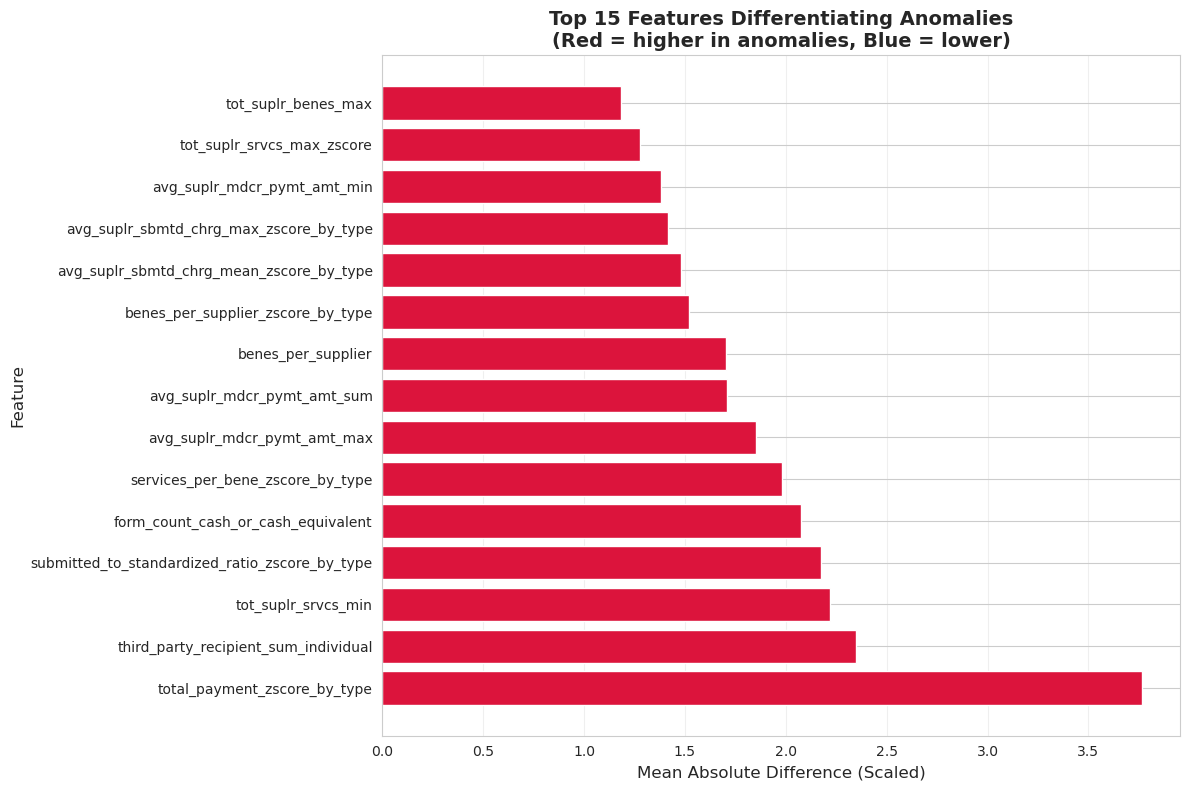

In [31]:
# Visualize top features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['crimson' if d > 0 else 'steelblue' for d in top_features['difference'].values]
plt.barh(range(top_n), top_features['importance'].values, color=colors)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Mean Absolute Difference (Scaled)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features Differentiating Anomalies\n(Red = higher in anomalies, Blue = lower)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# plt.savefig('inne_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualize Anomalies with PCA

In [32]:
# Apply PCA for 2D visualization
pca = PCA(n_components=50, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA Explained Variance Ratio: [0.16797845 0.11098007 0.09342322 0.0736685  0.05237543 0.04592845
 0.04010427 0.03284747 0.02712708 0.02600793 0.0228029  0.01973285
 0.01967379 0.017863   0.01675365 0.01519844 0.01490597 0.012828
 0.0111049  0.01064453 0.01005176 0.00948191 0.00909187 0.00889157
 0.00838179 0.00816576 0.00801894 0.00776626 0.00681938 0.00633051
 0.00596054 0.00571442 0.00533814 0.00501542 0.00469743 0.00456331
 0.00429317 0.00404717 0.00397272 0.00366513 0.00363574 0.00333513
 0.00330468 0.00315444 0.00262998 0.00228811 0.00206459 0.00194627
 0.00179793 0.00173246]
Total variance explained: 98.81%


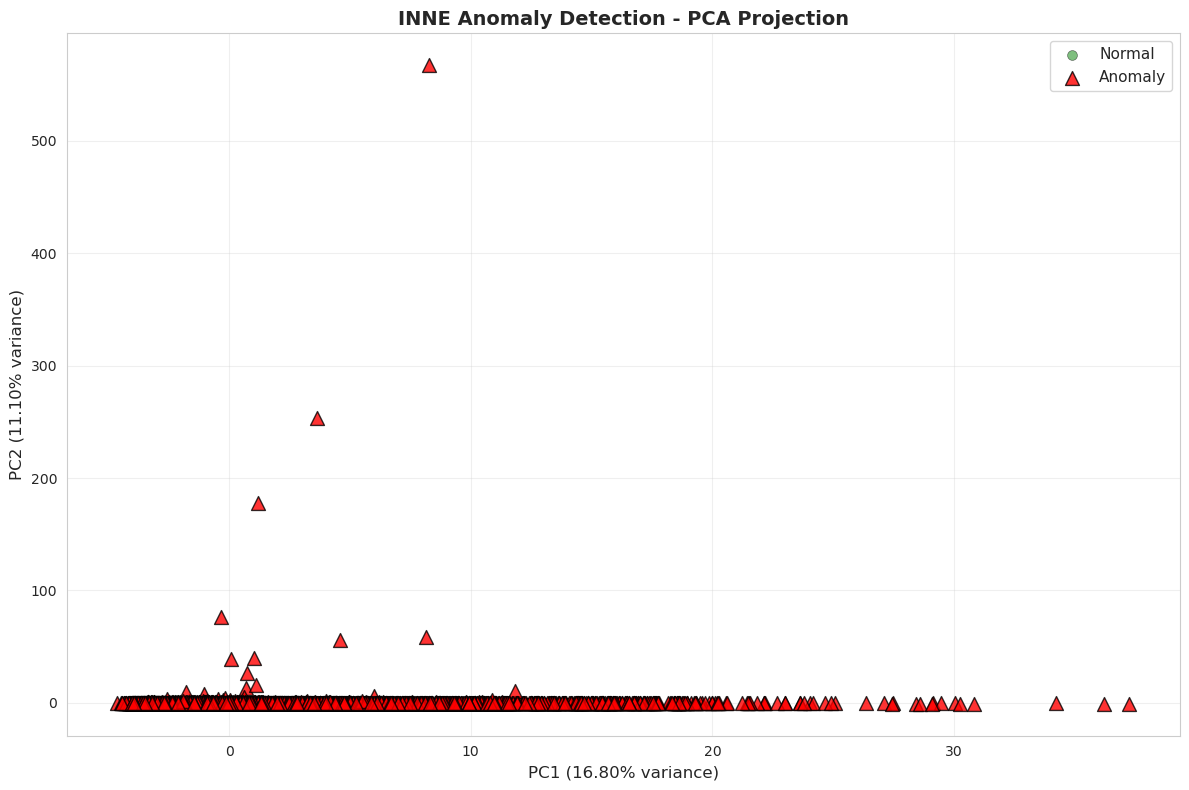

In [33]:
# Create visualization
plt.figure(figsize=(12, 8))

# Plot normal samples
normal_samples = X_test_pca[test_predictions == 1]
plt.scatter(normal_samples[:, 0], normal_samples[:, 1], 
            c='green', s=50, alpha=0.5, label='Normal', edgecolors='k', linewidth=0.5)

# Plot anomalies
anomaly_samples = X_test_pca[test_predictions == -1]
plt.scatter(anomaly_samples[:, 0], anomaly_samples[:, 1], 
            c='red', s=100, alpha=0.8, label='Anomaly', edgecolors='k', linewidth=1, marker='^')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('INNE Anomaly Detection - PCA Projection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('inne_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly Score Heatmap for Top Features

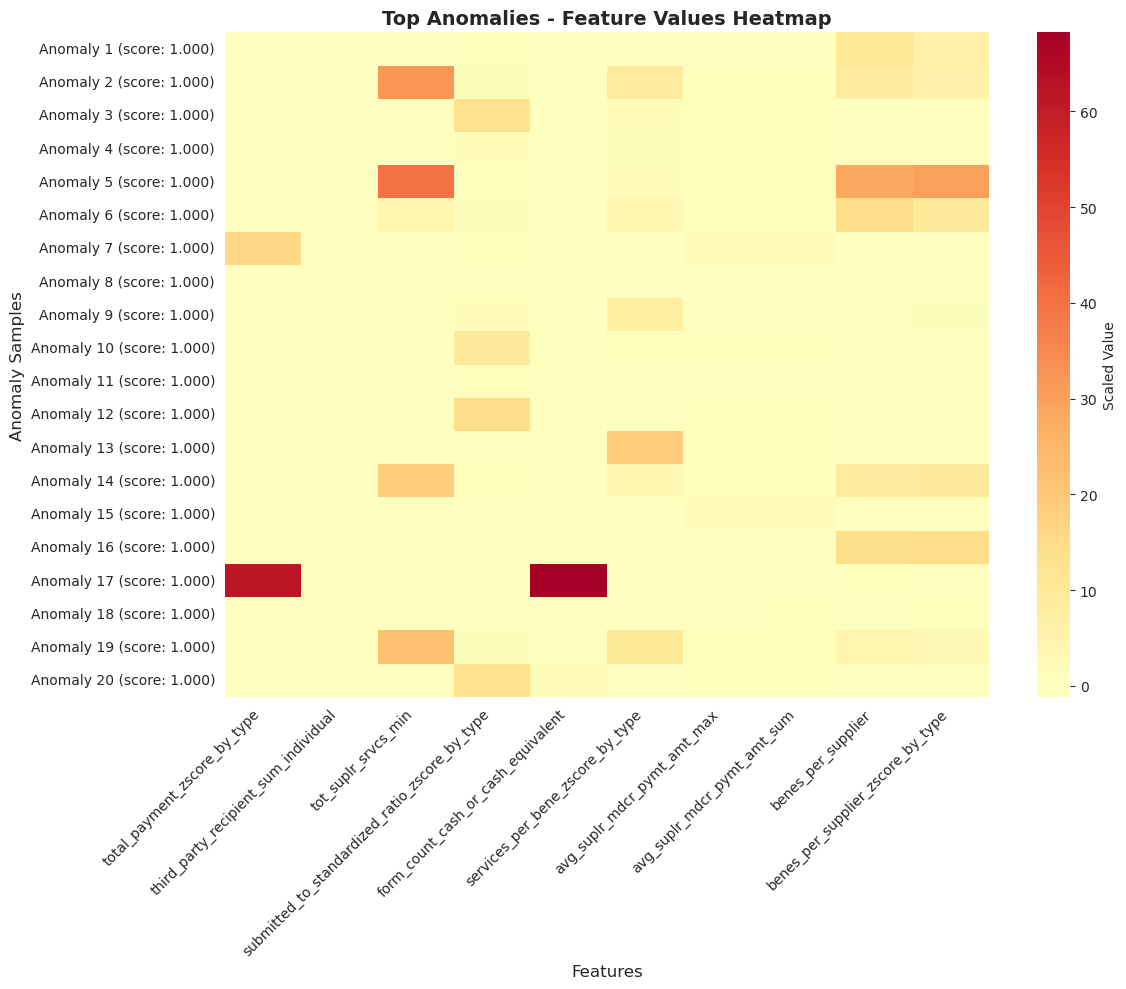

In [34]:
# Select top anomalies by highest score
n_top_anomalies = 20
top_anomaly_indices = np.argsort(test_scores)[-n_top_anomalies:][::-1]

# Get top features
top_feature_names = importance_df.head(10)['feature'].values
top_feature_indices = [feature_cols.index(f) for f in top_feature_names]

# Create heatmap data
heatmap_data = X_test_scaled[top_anomaly_indices][:, top_feature_indices]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            xticklabels=top_feature_names, 
            yticklabels=[f"Anomaly {i+1} (score: {test_scores[idx]:.3f})" 
                         for i, idx in enumerate(top_anomaly_indices)],
            cmap='RdYlGn_r', 
            center=0,
            cbar_kws={'label': 'Scaled Value'})
plt.title('Top Anomalies - Feature Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Anomaly Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('inne_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics and Recommendations

In [35]:
print("INNE FRAUD DETECTION SUMMARY")
print(f"\nModel Configuration (AUPRC-Tuned):")
print(f"  - n_estimators: {best_params['n_estimators']}")
print(f"  - max_samples: {best_params['max_samples']}")
print(f"  - contamination: {best_params['contamination']}")
print(f"  - Best AUPRC: {best_auprc:.4f} (+/- {best_auprc_std:.4f})")
print(f"  - Features Used: {len(feature_cols)}")

print(f"\nDataset:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")
print(f"  - Fraud in Training: {y_train.sum()}")
print(f"  - Fraud in Test: {y_test.sum()}")

print(f"\nAnomaly Detection Results (Test Set):")
print(f"  - Normal Transactions: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(test_predictions)*100:.2f}%)")
print(f"  - Anomalous Transactions: {(test_predictions == -1).sum()} ({(test_predictions == -1).sum()/len(test_predictions)*100:.2f}%)")

print(f"\nTop 5 Discriminative Features:")
for idx, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:40s} | Importance: {row['importance']:.4f} | Delta: {row['difference']:+.4f}")

print(f"\nPCA Visualization:")
print(f"  - Variance Explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Variance Explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

print(f"\nRecommendations:")
print(f"  1. Review flagged anomalies manually to validate fraud patterns")
print(f"  2. Model was tuned using AUPRC against known fraud labels")
print(f"  3. Monitor top discriminative features for unusual patterns")
print(f"  4. Use this model as part of the ensemble with Isolation Forest and ECOD")
print(f"  5. Regularly retrain the model with new data to adapt to evolving fraud patterns")

INNE FRAUD DETECTION SUMMARY

Model Configuration (AUPRC-Tuned):
  - n_estimators: 50
  - max_samples: 32
  - contamination: 0.001
  - Best AUPRC: 0.0019 (+/- 0.0020)
  - Features Used: 63

Dataset:
  - Total Samples: 140827
  - Training Samples: 84496
  - Test Samples: 56331
  - Fraud in Training: 34
  - Fraud in Test: 22

Anomaly Detection Results (Test Set):
  - Normal Transactions: 53515 (95.00%)
  - Anomalous Transactions: 2816 (5.00%)

Top 5 Discriminative Features:
  total_payment_zscore_by_type             | Importance: 3.7657 | Delta: +3.7657
  third_party_recipient_sum_individual     | Importance: 2.3488 | Delta: +2.3488
  tot_suplr_srvcs_min                      | Importance: 2.2183 | Delta: +2.2183
  submitted_to_standardized_ratio_zscore_by_type | Importance: 2.1740 | Delta: +2.1740
  form_count_cash_or_cash_equivalent       | Importance: 2.0759 | Delta: +2.0759

PCA Visualization:
  - Variance Explained by PC1: 16.80%
  - Variance Explained by PC2: 11.10%
  - Total Varian

## AUPRC Evaluation on Test Set

Test Set AUPRC: 0.0009
(Random baseline AUPRC ≈ 0.000391)


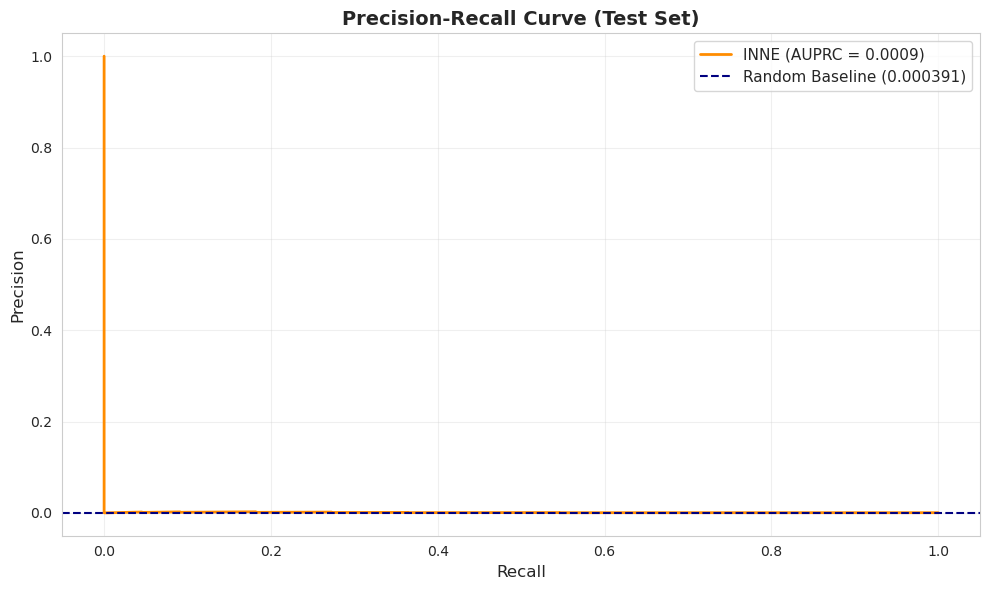

In [36]:
##############################################
# Evaluate AUPRC on test set using known fraud labels
###############################################
test_auprc = average_precision_score(y_test, test_scores)
print(f"Test Set AUPRC: {test_auprc:.4f}")
print(f"(Random baseline AUPRC ≈ {y_test.mean():.6f})")

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, color='darkorange', label=f'INNE (AUPRC = {test_auprc:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--', label=f'Random Baseline ({y_test.mean():.6f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve (Test Set)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('inne_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix (Top 5% Anomalous as Predicted Fraud)

Top 5% anomaly score threshold: 0.9534
Samples flagged as fraud (top 5%): 2817
Actual fraud in test set: 22

Confusion Matrix (top 5% threshold):
[[53496  2813]
 [   18     4]]

Classification Report (top 5% threshold):
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.95      0.97     56309
     Fraud (1)       0.00      0.18      0.00        22

      accuracy                           0.95     56331
     macro avg       0.50      0.57      0.49     56331
  weighted avg       1.00      0.95      0.97     56331



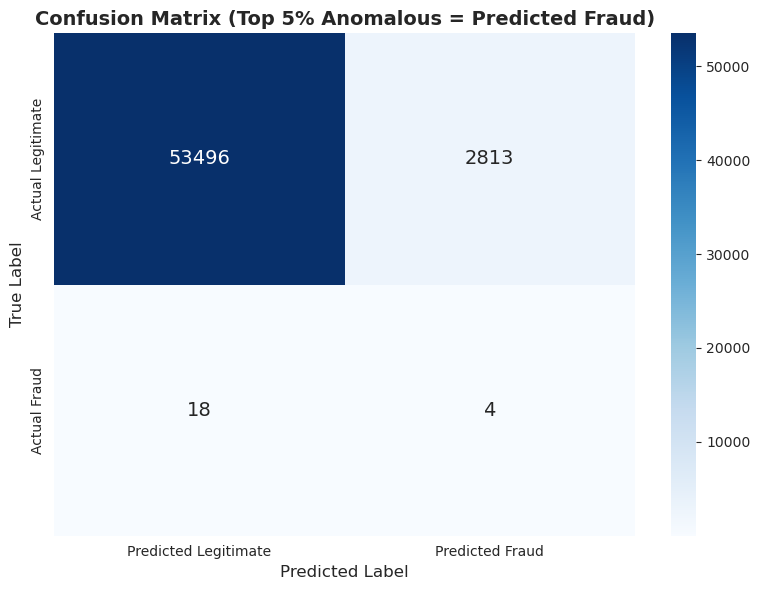


Detailed Metrics:
  True Positives (fraud caught): 4
  False Positives (legitimate flagged): 2813
  True Negatives (legitimate correct): 53496
  False Negatives (fraud missed): 18
  Precision: 0.0014
  Recall: 0.1818
  Fraud capture rate in top 5%: 4/22 = 18.2%


In [37]:
##############################################
# Confusion Matrix: top 5% most anomalous = predicted fraud (1)
###############################################
top_5pct_threshold = np.percentile(test_scores, 95)
y_pred_top5 = (test_scores >= top_5pct_threshold).astype(int)

print(f"Top 5% anomaly score threshold: {top_5pct_threshold:.4f}")
print(f"Samples flagged as fraud (top 5%): {y_pred_top5.sum()}")
print(f"Actual fraud in test set: {y_test.sum()}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_top5)
print(f"\nConfusion Matrix (top 5% threshold):")
print(cm)

# Classification report
print(f"\nClassification Report (top 5% threshold):")
print(classification_report(y_test, y_pred_top5, target_names=['Legitimate (0)', 'Fraud (1)']))

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Top 5% Anomalous = Predicted Fraud)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('inne_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Metrics:")
print(f"  True Positives (fraud caught): {tp}")
print(f"  False Positives (legitimate flagged): {fp}")
print(f"  True Negatives (legitimate correct): {tn}")
print(f"  False Negatives (fraud missed): {fn}")
print(f"  Precision: {tp/(tp+fp):.4f}" if (tp+fp) > 0 else "  Precision: N/A")
print(f"  Recall: {tp/(tp+fn):.4f}" if (tp+fn) > 0 else "  Recall: N/A")
print(f"  Fraud capture rate in top 5%: {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%" if (tp+fn) > 0 else "")

## Save Model and Artifacts for Ensemble Integration

In [38]:
# Save the trained model
# NOTE: Saved as 'inne_model.pkl' — update ensemble_scorer config to reference this
joblib.dump(inne_model, 'inne_model.pkl')
print("Model saved to 'inne_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'inne_scaler.pkl')
print("Scaler saved to 'inne_scaler.pkl'")

# Save reference scores for z-score normalization in ensemble
reference_data = {
    'train_scores': train_scores,
    'train_mean': float(train_scores.mean()),
    'train_std': float(train_scores.std()),
    'threshold': float(np.percentile(train_scores, 95)),
    'feature_cols': feature_cols,
    'feature_importance': importance_df.set_index('feature')['importance'].to_dict(),
    'best_params': best_params,
    'best_auprc': float(best_auprc),
    'best_auprc_std': float(best_auprc_std)
}
joblib.dump(reference_data, 'inne_reference_scores.pkl')
print("Reference scores saved to 'inne_reference_scores.pkl'")

print(f"\nReference Statistics:")
print(f"  - Training Score Mean: {reference_data['train_mean']:.4f}")
print(f"  - Training Score Std: {reference_data['train_std']:.4f}")
print(f"  - 95th Percentile Threshold: {reference_data['threshold']:.4f}")

Model saved to 'inne_model.pkl'
Scaler saved to 'inne_scaler.pkl'
Reference scores saved to 'inne_reference_scores.pkl'

Reference Statistics:
  - Training Score Mean: 0.6287
  - Training Score Std: 0.2125
  - 95th Percentile Threshold: 0.9564


In [39]:
# Create output DataFrame with predictions and scores
output_df = X_test.copy()
output_df['anomaly_score'] = test_scores
output_df['is_anomaly'] = (test_predictions == -1).astype(int)
output_df['prediction'] = test_predictions

# Sort by anomaly score (most anomalous first)
output_df = output_df.sort_values('anomaly_score', ascending=False)

print("Top 10 Most Anomalous Samples:")
print(output_df[['anomaly_score', 'is_anomaly', 'prediction']].head(10))

# Export to CSV
output_df.to_csv('inne_predictions.csv', index=True)
print("\nPredictions exported to 'inne_predictions.csv'")

Top 10 Most Anomalous Samples:
        anomaly_score  is_anomaly  prediction
56939             1.0           1          -1
60316             1.0           1          -1
118368            1.0           1          -1
117700            1.0           1          -1
101875            1.0           1          -1
135072            1.0           1          -1
55040             1.0           1          -1
125963            1.0           1          -1
97942             1.0           1          -1
65416             1.0           1          -1

Predictions exported to 'inne_predictions.csv'
